# Prediction of Product Sales

**Author:** Salam Odeh

**Goal:** Help a retailer understand which product and outlet properties drive
sales, and build a machine learning model to predict `Item_Outlet_Sales`.

**Dataset:** `sales_predictions_2023.csv` — 8,523 product-outlet combinations
across 10 stores.

**Process:** CRISP-DM — Business Understanding → Data Understanding →
Data Preparation → Modeling → Evaluation → Deployment

---
## Table of Contents
1. Imports and Custom Functions
2. Load and Inspect Data (CRISP-DM Phase 2)
3. Clean Data (CRISP-DM Phase 3a)
4. Feature Engineering
5. Exploratory Data Analysis (CRISP-DM Phase 3b)
6. Feature Inspection (CRISP-DM Phase 3c)
7. Preprocessing — Avoid Data Leakage (CRISP-DM Phase 3d)
8. Regression Modeling (CRISP-DM Phase 4)
9. Classification Modeling (CRISP-DM Phase 4b)
10. Model Insights — Feature Importance and Coefficients
11. Prediction Function
12. Final Evaluation and Recommendation (CRISP-DM Phase 5)

---
## 1. Imports and Custom Functions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    root_mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

from sklearn import set_config
set_config(transform_output='pandas')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:,.4f}'.format)
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ── Regression Evaluation ────────────────────────────────────────────────
def evaluate_regression(reg, X_train, y_train, X_test, y_test, label=''):
    """Print train/test MAE, MSE, RMSE, R² for any regression model."""
    if label:
        print(f'\n{"=" * 60}\n  {label}\n{"=" * 60}')
    for split_name, X, y in [('Training Data', X_train, y_train),
                               ('Test Data',     X_test,  y_test)]:
        pred = reg.predict(X)
        print('-' * 55)
        print(f'Regression Metrics: {split_name}')
        print('-' * 55)
        print(f'  MAE  = {mean_absolute_error(y, pred):,.3f}')
        print(f'  MSE  = {mean_squared_error(y, pred):,.3f}')
        print(f'  RMSE = {root_mean_squared_error(y, pred):,.3f}')
        print(f'  R²   = {r2_score(y, pred):,.3f}')
        print()


# ── Classification Evaluation ────────────────────────────────────────────
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                              label='', output_frame=False):
    """Print accuracy, classification report, and confusion matrix."""
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    train_acc    = accuracy_score(y_train, y_train_pred)
    test_acc     = accuracy_score(y_test,  y_test_pred)

    print(f'\n{"=" * 60}\n  {label}\n{"=" * 60}')
    print(f'  Training Accuracy : {train_acc:.4f} ({train_acc * 100:.2f}%)')
    print(f'  Test Accuracy     : {test_acc:.4f} ({test_acc * 100:.2f}%)')
    gap = train_acc - test_acc
    print(f'  Train-Test Gap    : {gap:.4f}',
          '[!] Overfit!' if gap > 0.10 else '[OK]')
    print()
    print(classification_report(
        y_test, y_test_pred,
        target_names=['Below Median', 'Above Median']
    ))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Below Median', 'Above Median'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'Counts — {label}')
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=['Below Median', 'Above Median'],
        normalize='true', cmap='Blues', ax=axes[1]
    )
    axes[1].set_title(f'Normalized — {label}')
    fig.tight_layout()
    plt.show()

    if output_frame:
        cm = confusion_matrix(y_test, y_test_pred)
        tn, fp, fn, tp = cm.ravel()
        return pd.Series({
            'Train Acc' : round(train_acc, 4),
            'Test Acc'  : round(test_acc,  4),
            'Precision' : round(precision_score(y_test, y_test_pred), 4),
            'Recall'    : round(recall_score(y_test,    y_test_pred), 4),
            'F1'        : round(f1_score(y_test,        y_test_pred), 4),
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        }, name=label)


# ── Feature Importance ───────────────────────────────────────────────────
def get_importances(model, feature_names, top_n=None):
    """Extract sorted built-in feature importances from a tree model/pipeline."""
    if hasattr(model, 'named_steps'):
        for step in model.named_steps.values():
            if hasattr(step, 'feature_importances_'):
                importances = step.feature_importances_
                break
    else:
        importances = model.feature_importances_
    s = pd.Series(importances, index=feature_names, name='Importance')
    s = s.sort_values(ascending=False)
    return s.head(top_n) if top_n else s


def get_coeffs_linreg(pipeline):
    """Extract coefficients from a fitted Linear Regression pipeline,
    sorted by absolute value (largest impact first)."""
    fn = pipeline.named_steps['columntransformer'].get_feature_names_out()
    c  = pipeline.named_steps['linearregression'].coef_
    s  = pd.Series(c, index=fn, name='Coefficient')
    return s.reindex(s.abs().sort_values(ascending=False).index)


def plot_importance(importances, top_n=15, figsize=(8, 6), title=None):
    """Horizontal bar chart of top N feature importances."""
    plot_data = importances.head(top_n).sort_values(ascending=True)
    colors    = ['steelblue'] * len(plot_data)
    colors[-1] = 'darkorange'   # highlight top feature
    fig, ax = plt.subplots(figsize=figsize)
    plot_data.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(title or f'Top {top_n} Most Important Features',
                  fontweight='bold')
    ax.set_xlabel('Importance')
    fig.tight_layout()
    plt.show()
    return fig, ax


def plot_coeffs(coeffs, top_n=15, figsize=(8, 7),
                 color_pos='green', color_neg='red',
                 label_pos='Increases Sales',
                 label_neg='Decreases Sales',
                 title=None):
    """Color-coded horizontal bar chart of top N regression coefficients."""
    plot_data = coeffs.head(top_n).sort_values(ascending=True)
    colors    = [color_pos if v > 0 else color_neg for v in plot_data]
    fig, ax   = plt.subplots(figsize=figsize)
    plot_data.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    for bar in ax.patches:
        w = bar.get_width()
        x = bar.get_x() + w
        y = bar.get_y() + bar.get_height() / 2
        ax.annotate(f'{w:,.0f}', xy=(x, y), va='center',
                    ha='left' if w >= 0 else 'right', fontsize=8)
    ax.set_title(title or f'Top {top_n} Largest Coefficients',
                  fontweight='bold')
    ax.set_xlabel('Coefficient')
    pp  = mpatches.Patch(color=color_pos, label=label_pos)
    np_ = mpatches.Patch(color=color_neg, label=label_neg)
    ax.legend(handles=[pp, np_], loc='lower right')
    fig.tight_layout()
    return fig, ax


# ── Prediction Convenience Function ─────────────────────────────────────
def predict_sales(model, item_mrp, outlet_type, item_type,
                   item_fat_content='Low Fat', outlet_size='Medium',
                   outlet_location_type='Tier 2', outlet_identifier='OUT027',
                   item_weight=12.0, item_visibility=0.066, outlet_age=20):
    """
    Predict sales for a single product-outlet combination.

    Parameters:
    -----------
    model                : fitted pipeline (must include Outlet_Age feature)
    item_mrp             : float  — product list price
    outlet_type          : str    — 'Grocery Store' / 'Supermarket Type1/2/3'
    item_type            : str    — product category (e.g. 'Snack Foods')
    item_fat_content     : str    — 'Low Fat' or 'Regular'
    outlet_size          : str    — 'Small', 'Medium', or 'High'
    outlet_location_type : str    — 'Tier 1', 'Tier 2', or 'Tier 3'
    outlet_identifier    : str    — store ID (e.g. 'OUT027')
    item_weight          : float  — product weight (default = dataset median ~12)
    item_visibility      : float  — display visibility (default = dataset mean)
    outlet_age           : int    — years since the store was established

    Returns:
    --------
    float — predicted Item_Outlet_Sales in dollars
    """
    sample = pd.DataFrame([{
        'Item_Weight'          : item_weight,
        'Item_Fat_Content'     : item_fat_content,
        'Item_Visibility'      : item_visibility,
        'Item_Type'            : item_type,
        'Item_MRP'             : item_mrp,
        'Outlet_Identifier'    : outlet_identifier,
        'Outlet_Size'          : outlet_size,
        'Outlet_Location_Type' : outlet_location_type,
        'Outlet_Type'          : outlet_type,
        'Outlet_Age'           : outlet_age
    }])
    prediction = model.predict(sample)[0]
    print(f'Predicted Sales: ${prediction:,.2f}')
    return prediction


# ── Metrics helper for comparison table ─────────────────────────────────
def get_metrics(model, X_test, y_test, label):
    """Return a pd.Series of test-set regression metrics."""
    pred = model.predict(X_test)
    return pd.Series({
        'Test R²'   : round(r2_score(y_test, pred), 4),
        'Test MAE'  : round(mean_absolute_error(y_test, pred), 2),
        'Test RMSE' : round(root_mean_squared_error(y_test, pred), 2),
    }, name=label)

---
## 2. Load and Inspect Data (CRISP-DM Phase 2)

In [4]:
# Load a fresh copy of the original uncleaned dataset
fpath = 'sales_predictions_2023.csv'
df = pd.read_csv(fpath)

print(f'Shape: {df.shape}')
df.head()

Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.3000,Low Fat,0.0160,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,"3,735.1380"
1,DRC01,5.9200,Regular,0.0193,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.5000,Low Fat,0.0168,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,"2,097.2700"
3,FDX07,19.2000,Regular,0.0000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.9300,Low Fat,0.0000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [5]:
# 1) Rows and columns
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')

# 2) Datatypes
df.info()

# 3) Duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

# 4) Missing values
print('\nMissing values:')
print(df.isna().sum())

Rows: 8,523   Columns: 12
<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB

Duplicate rows: 0

Missing values

---
## 3. Clean Data (CRISP-DM Phase 3a)

In [6]:
# Drop duplicates
df = df.drop_duplicates()

# 5) Address missing values with placeholders for initial EDA
# (in Part 7 we restore real nulls before the train/test split)
df['Item_Weight'] = df['Item_Weight'].fillna(0)          # numeric placeholder
df['Outlet_Size'] = df['Outlet_Size'].fillna('MISSING')  # categorical placeholder

# 6) Confirm no missing values remain
print('Missing values after addressing:')
print(df.isna().sum())

Missing values after addressing:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


In [7]:
# 7) Fix inconsistent categories in Item_Fat_Content
print('Before fix:')
print(df['Item_Fat_Content'].value_counts())

df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'
})

print('\nAfter fix:')
print(df['Item_Fat_Content'].value_counts())

Before fix:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

After fix:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [8]:
# 8) Summary statistics for numerical columns (min, max, mean)
df.describe().loc[['min', 'max', 'mean']].round(2)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,0.0000,0.0000,31.2900,"1,985.0000",33.2900
max,21.3500,0.3300,266.8900,"2,009.0000","13,086.9600"
mean,10.6500,0.0700,140.9900,"1,997.8300","2,181.2900"


---
## 4. Feature Engineering (Enhancement)

We create `Outlet_Age` from `Outlet_Establishment_Year`.
This is more intuitive than the raw year and improves model performance.

In [9]:
# First: restore actual nulls (remove placeholders used only for EDA)
df['Item_Weight'] = df['Item_Weight'].replace(0, np.nan)
df['Outlet_Size'] = df['Outlet_Size'].replace('MISSING', np.nan)

# Create Outlet_Age: years since the store was established (as of 2024)
df['Outlet_Age'] = 2024 - df['Outlet_Establishment_Year']

# Drop the original year column — now redundant
df = df.drop(columns=['Outlet_Establishment_Year'])

print('Outlet_Age added:')
print(df['Outlet_Age'].describe().round(1))
print(f'\nCurrent columns: {df.columns.tolist()}')

Outlet_Age added:
count   8,523.0000
mean       26.2000
std         8.4000
min        15.0000
25%        20.0000
50%        25.0000
75%        37.0000
max        39.0000
Name: Outlet_Age, dtype: float64

Current columns: ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales', 'Outlet_Age']


---
## 5. Exploratory Data Analysis (CRISP-DM Phase 3b)

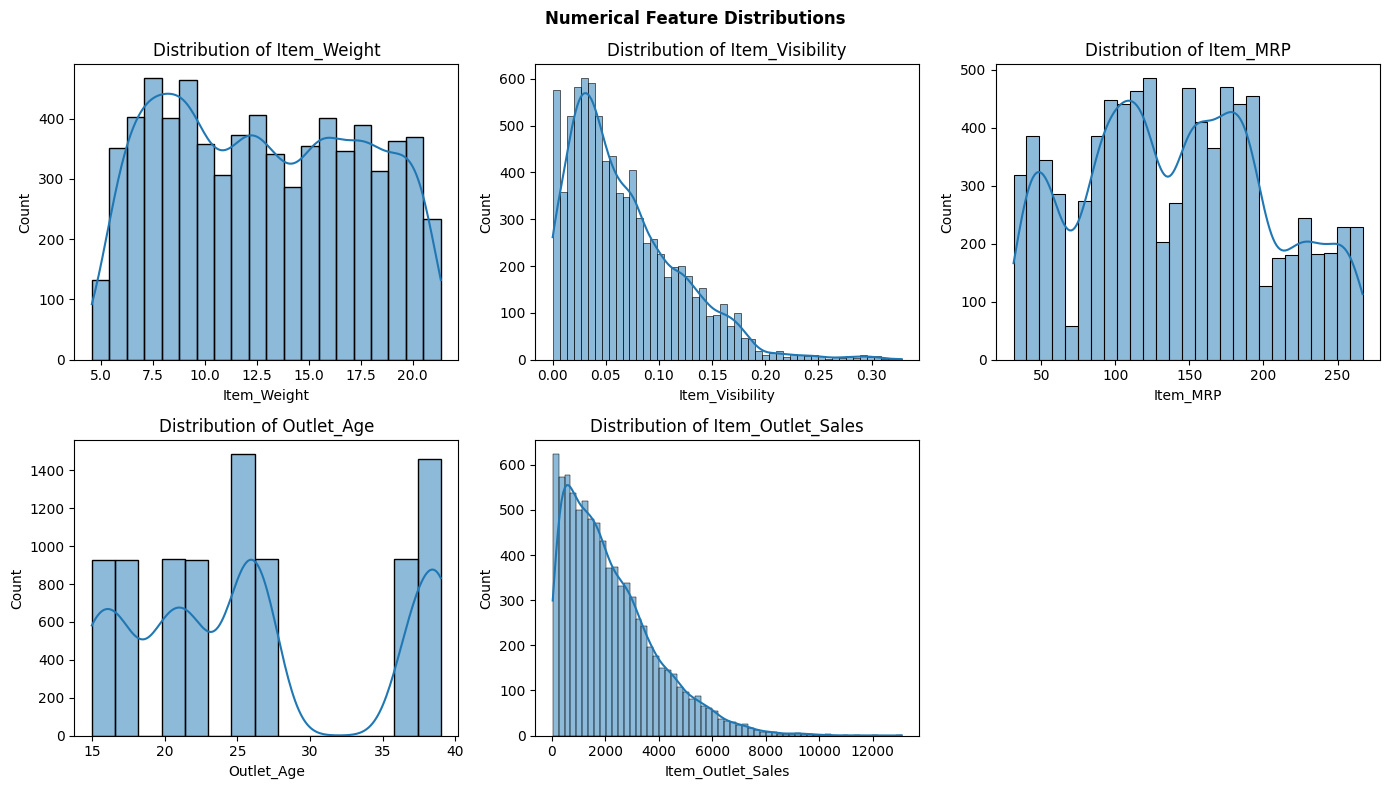

In [10]:
# Histograms — all numeric features
num_cols_eda = ['Item_Weight', 'Item_Visibility', 'Item_MRP',
                'Outlet_Age', 'Item_Outlet_Sales']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols_eda):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')
axes[-1].set_visible(False)   # hide 6th panel (only 5 features)
fig.suptitle('Numerical Feature Distributions', fontweight='bold')
fig.tight_layout()
plt.show()

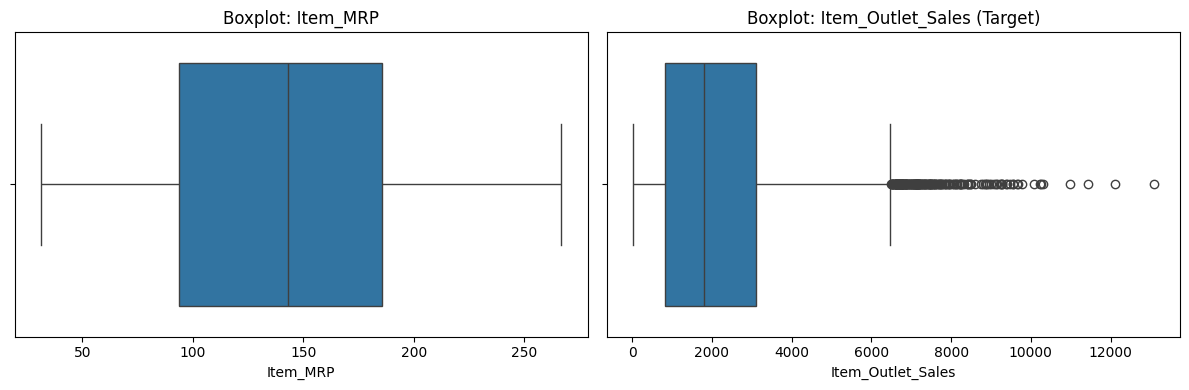

In [11]:
# Boxplots — key numeric features vs target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='Item_MRP', ax=axes[0])
axes[0].set_title('Boxplot: Item_MRP')
sns.boxplot(data=df, x='Item_Outlet_Sales', ax=axes[1])
axes[1].set_title('Boxplot: Item_Outlet_Sales (Target)')
fig.tight_layout()
plt.show()

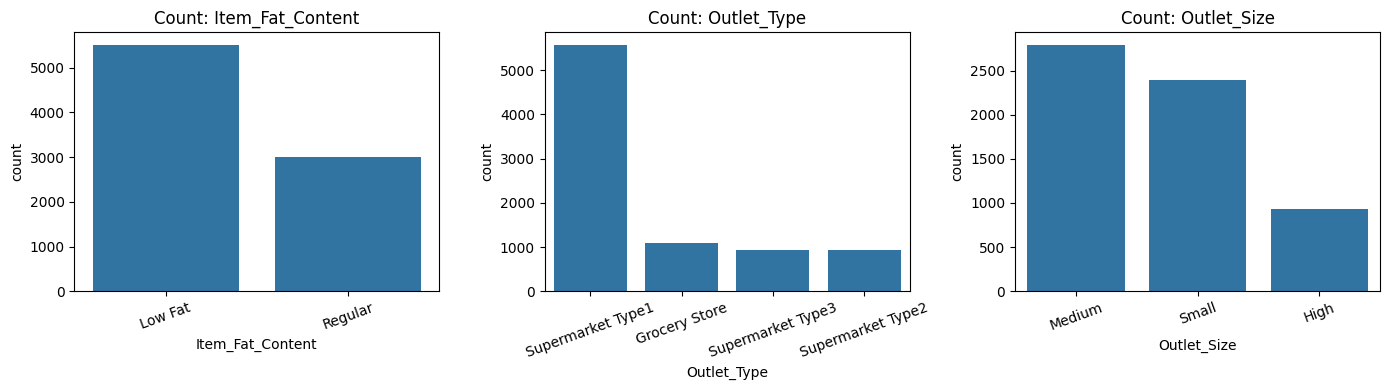

In [12]:
# Countplots — categorical features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes,
    ['Item_Fat_Content', 'Outlet_Type', 'Outlet_Size']):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=ax, order=order)
    ax.set_title(f'Count: {col}')
    ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
plt.show()

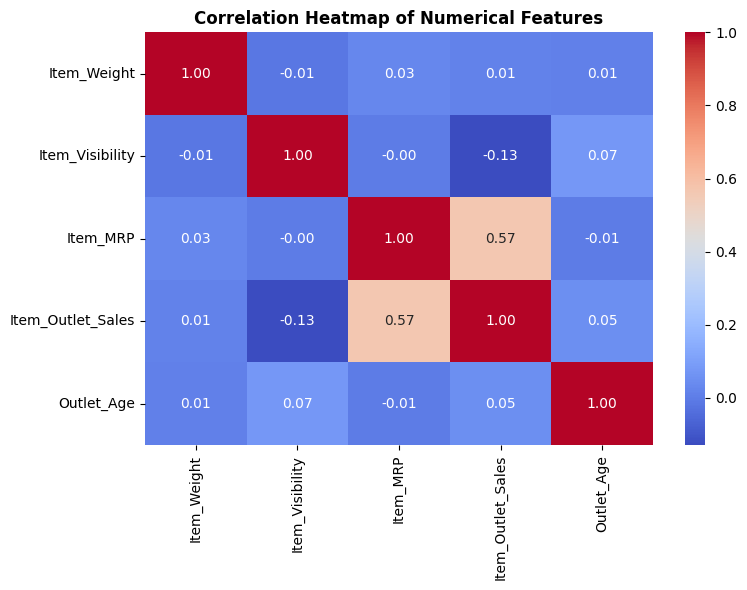

In [13]:
# Correlation heatmap — numeric features
corr = df.select_dtypes('number').corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features', fontweight='bold')
fig.tight_layout()
plt.show()

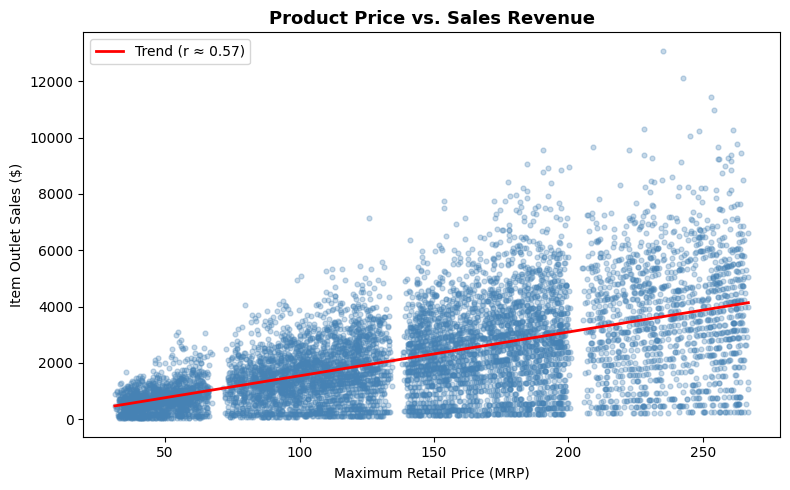

Saved: insight1_price_vs_sales.png  (→ use in README)


In [14]:
# Insight 1: Item_MRP vs Item_Outlet_Sales (reporting-quality)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Item_MRP'], df['Item_Outlet_Sales'],
           alpha=0.3, s=12, color='steelblue')
m, b = np.polyfit(df['Item_MRP'], df['Item_Outlet_Sales'], 1)
x_line = np.linspace(df['Item_MRP'].min(), df['Item_MRP'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label='Trend (r ≈ 0.57)')
ax.set_title('Product Price vs. Sales Revenue', fontweight='bold', fontsize=13)
ax.set_xlabel('Maximum Retail Price (MRP)')
ax.set_ylabel('Item Outlet Sales ($)')
ax.legend()
fig.tight_layout()
fig.savefig('insight1_price_vs_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: insight1_price_vs_sales.png  (→ use in README)')

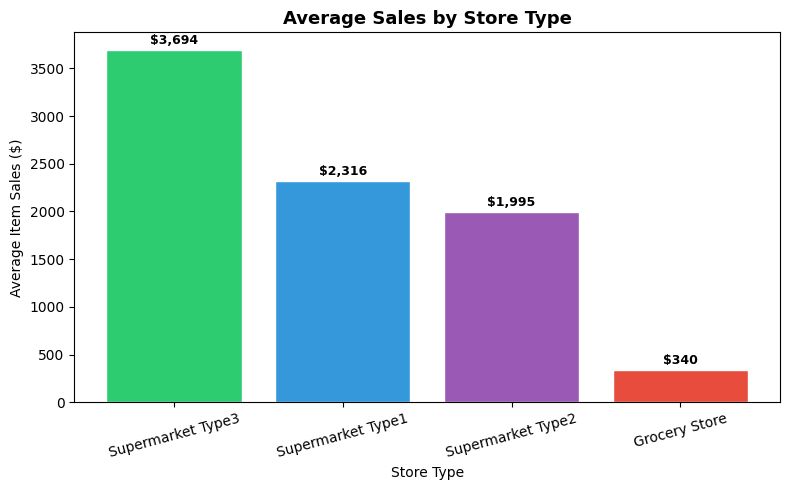

Saved: insight2_sales_by_outlet_type.png  (→ use in README)


In [15]:
# Insight 2: Average sales by Outlet_Type (reporting-quality)
avg_sales = (df.groupby('Outlet_Type')['Item_Outlet_Sales']
               .mean()
               .sort_values(ascending=False))
colors_bar = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(avg_sales.index, avg_sales.values,
               color=colors_bar, edgecolor='white')
ax.set_title('Average Sales by Store Type', fontweight='bold', fontsize=13)
ax.set_xlabel('Store Type')
ax.set_ylabel('Average Item Sales ($)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, avg_sales.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 30,
             f'${val:,.0f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
fig.tight_layout()
fig.savefig('insight2_sales_by_outlet_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: insight2_sales_by_outlet_type.png  (→ use in README)')

---
## 6. Feature Inspection (CRISP-DM Phase 3c)

Key findings from the full per-feature inspection (see `Part4_Feature_Inspection.ipynb`
for the complete analysis):

| Feature | Type | Nulls | Action | Key Finding |
|---|---|---|---|---|
| Item_Identifier | Categorical (nominal) | 0 | **Drop** — 1,559 unique IDs, no predictive value | High cardinality |
| Item_Weight | Numeric | 17.2% | Impute with median | Weak predictor |
| Item_Fat_Content | Categorical (nominal) | 0 | Keep — fix labels | Weak predictor |
| Item_Visibility | Numeric | 0 | Keep | Moderate predictor |
| Item_Type | Categorical (nominal) | 0 | Keep | Moderate predictor |
| Item_MRP | Numeric | 0 | Keep | **Strongest predictor (r=0.57)** |
| Outlet_Identifier | Categorical (nominal) | 0 | Keep | Outlet-specific effects |
| Outlet_Age | Numeric (engineered) | 0 | Keep | Replaces Establishment_Year |
| Outlet_Size | Categorical (ordinal) | 28.3% | Impute with 'MISSING' | Moderate predictor |
| Outlet_Location_Type | Categorical (ordinal) | 0 | Keep | Moderate predictor |
| Outlet_Type | Categorical (nominal) | 0 | Keep | **2nd strongest predictor** |

---
## 7. Preprocessing — Avoid Data Leakage (CRISP-DM Phase 3d)

**Critical rule:** all imputation statistics (medians, modes) are learned
from TRAINING data only, then applied to both train and test.

In [16]:
# Define X (features) and y (target)
y = df['Item_Outlet_Sales']
X = df.drop(columns=['Item_Outlet_Sales', 'Item_Identifier'])

# Train-test split BEFORE any imputation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'Training: {X_train.shape} | Testing: {X_test.shape}')
print(f'\nMissing values in X_train:')
print(X_train.isna().sum()[X_train.isna().sum() > 0])

Training: (6392, 10) | Testing: (2131, 10)

Missing values in X_train:
Item_Weight    1107
Outlet_Size    1812
dtype: int64


In [17]:
# Identify column types from training data only
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object', 'str']).columns

print('Numeric columns:',    num_cols.tolist())
print('Categorical columns:', cat_cols.tolist())

Numeric columns: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
Categorical columns: ['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [18]:
# Numeric pipeline: median imputation + StandardScaler
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# Categorical pipeline: MISSING placeholder + OneHotEncoder
# drop='if_binary' avoids the dummy variable trap for Linear Regression
cat_pipe = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='MISSING'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary')
)

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    [('num', num_pipe, num_cols),
     ('cat', cat_pipe, cat_cols)],
    verbose_feature_names_out=False
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The

---
## 8. Regression Modeling — Predicting Exact Sales (CRISP-DM Phase 4)

In [19]:
# ── Baseline: Always predict the mean (Enhancement) ─────────────────────
# A good model must beat this naive baseline.
# Baseline R² ≈ 0.00 by definition (predicting a constant)
dummy = make_pipeline(preprocessor, DummyRegressor(strategy='mean'))
dummy.fit(X_train, y_train)
evaluate_regression(dummy, X_train, y_train, X_test, y_test,
                     label='Baseline — Always Predict Mean')


  Baseline — Always Predict Mean
-------------------------------------------------------
Regression Metrics: Training Data
-------------------------------------------------------
  MAE  = 1,360.218
  MSE  = 2,959,455.705
  RMSE = 1,720.307
  R²   = 0.000

-------------------------------------------------------
Regression Metrics: Test Data
-------------------------------------------------------
  MAE  = 1,326.121
  MSE  = 2,772,144.463
  RMSE = 1,664.976
  R²   = -0.005



In [20]:
# ── Task 1: Linear Regression ────────────────────────────────────────────
lr_pipe = make_pipeline(preprocessor, LinearRegression())
lr_pipe.fit(X_train, y_train)
evaluate_regression(lr_pipe, X_train, y_train, X_test, y_test,
                     label='Linear Regression')


  Linear Regression
-------------------------------------------------------
Regression Metrics: Training Data
-------------------------------------------------------
  MAE  = 847.129
  MSE  = 1,297,558.136
  RMSE = 1,139.104
  R²   = 0.562

-------------------------------------------------------
Regression Metrics: Test Data
-------------------------------------------------------
  MAE  = 804.120
  MSE  = 1,194,349.715
  RMSE = 1,092.863
  R²   = 0.567



**Assessment — Linear Regression:**
- Test R² ≈ 0.567 — a large improvement over the baseline (R² ≈ 0.00)
- Train-test gap < 0.01 → **not overfit**, but moderately underfit
- Linear model cannot capture the non-linear relationships in this data

In [21]:
# ── Task 2: Default Random Forest ───────────────────────────────────────
rf_pipe = make_pipeline(
    preprocessor,
    RandomForestRegressor(random_state=42)
)
rf_pipe.fit(X_train, y_train)
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test,
                     label='Default Random Forest')


  Default Random Forest
-------------------------------------------------------
Regression Metrics: Training Data
-------------------------------------------------------
  MAE  = 296.691
  MSE  = 183,376.745
  RMSE = 428.225
  R²   = 0.938

-------------------------------------------------------
Regression Metrics: Test Data
-------------------------------------------------------
  MAE  = 765.846
  MSE  = 1,214,942.509
  RMSE = 1,102.244
  R²   = 0.560



**Assessment — Default Random Forest:**
- Train R² ≈ 0.94, Test R² ≈ 0.56 → **heavily overfit** (gap ≈ 0.38)
- Test performance comparable to Linear Regression
- GridSearchCV tuning is needed to reduce overfitting

In [22]:
# ── Task 3: Tuned Random Forest (GridSearchCV) ──────────────────────────
param_grid = {
    'randomforestregressor__n_estimators'    : [50, 100],
    'randomforestregressor__max_depth'       : [None, 5, 10],
    'randomforestregressor__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    rf_pipe, param_grid,
    cv=3, n_jobs=-1, scoring='r2', verbose=1
)
grid_search.fit(X_train, y_train)

print('\nBest parameters:', grid_search.best_params_)
print(f'Best CV R²: {grid_search.best_score_:.4f}')

best_rf = grid_search.best_estimator_
evaluate_regression(best_rf, X_train, y_train, X_test, y_test,
                     label='Tuned Random Forest (GridSearchCV) ✅')

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best parameters: {'randomforestregressor__max_depth': 5, 'randomforestregressor__min_samples_leaf': 1, 'randomforestregressor__n_estimators': 100}
Best CV R²: 0.5952

  Tuned Random Forest (GridSearchCV) ✅
-------------------------------------------------------
Regression Metrics: Training Data
-------------------------------------------------------
  MAE  = 755.398
  MSE  = 1,152,593.314
  RMSE = 1,073.589
  R²   = 0.611

-------------------------------------------------------
Regression Metrics: Test Data
-------------------------------------------------------
  MAE  = 728.408
  MSE  = 1,096,403.840
  RMSE = 1,047.093
  R²   = 0.603



In [23]:
# ── Regression Model Comparison ──────────────────────────────────────────
reg_comparison = pd.DataFrame([
    get_metrics(dummy,    X_test, y_test, 'Baseline (Mean)'),
    get_metrics(lr_pipe,  X_test, y_test, 'Linear Regression'),
    get_metrics(rf_pipe,  X_test, y_test, 'Random Forest (default)'),
    get_metrics(best_rf,  X_test, y_test, 'Random Forest (tuned) ✅'),
])
print('=== Regression Model Comparison ===')
reg_comparison

=== Regression Model Comparison ===


,Test R²,Test MAE,Test RMSE
Baseline (Mean),-0.0048,"1,326.1200","1,664.9800"
Linear Regression,0.5671,804.1200,"1,092.8600"
Random Forest (default),0.5596,765.8500,"1,102.2400"
Random Forest (tuned) ✅,0.6026,728.4100,"1,047.0900"


---
## 9. Classification Modeling — High vs. Low Seller (CRISP-DM Phase 4b)

Converting the regression target to binary classification:
split at the **median** sales value to create balanced classes.

In [24]:
# Create binary classification target
median_sales = df['Item_Outlet_Sales'].median()
print(f'Median Item_Outlet_Sales: ${median_sales:,.2f}')

y_cls = (df['Item_Outlet_Sales'] > median_sales).astype(int)
X_cls = df.drop(columns=['Item_Outlet_Sales', 'Item_Identifier'])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42
)

print(f'\nClass balance (training):')
print(y_train_c.value_counts(normalize=True).round(3))

Median Item_Outlet_Sales: $1,794.33

Class balance (training):
Item_Outlet_Sales
1   0.5030
0   0.4970
Name: proportion, dtype: float64


In [25]:
# Rebuild preprocessor for classification (same structure)
num_cols_c = X_train_c.select_dtypes(include=['number']).columns
cat_cols_c = X_train_c.select_dtypes(include=['object', 'str']).columns

preprocessor_c = ColumnTransformer(
    [('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols_c),
     ('cat', make_pipeline(
         SimpleImputer(strategy='constant', fill_value='MISSING'),
         OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary')
     ), cat_cols_c)],
    verbose_feature_names_out=False
)


  Default Decision Tree
  Training Accuracy : 1.0000 (100.00%)
  Test Accuracy     : 0.7433 (74.33%)
  Train-Test Gap    : 0.2567 [!] Overfit!

              precision    recall  f1-score   support

Below Median       0.75      0.74      0.75      1090
Above Median       0.73      0.75      0.74      1041

    accuracy                           0.74      2131
   macro avg       0.74      0.74      0.74      2131
weighted avg       0.74      0.74      0.74      2131



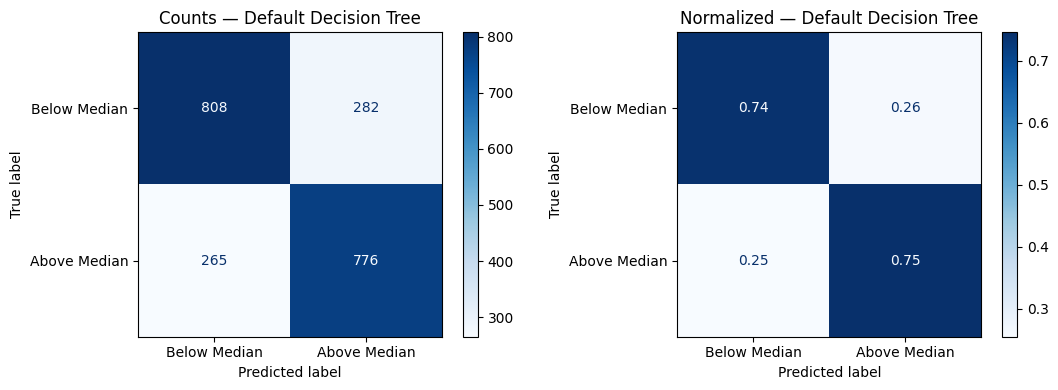

In [26]:
# Default Decision Tree Classifier (baseline)
dt_pipe = make_pipeline(
    preprocessor_c,
    DecisionTreeClassifier(random_state=42)
)
dt_pipe.fit(X_train_c, y_train_c)
dt_results = evaluate_classification(
    dt_pipe, X_train_c, y_train_c, X_test_c, y_test_c,
    label='Default Decision Tree', output_frame=True
)

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best classification params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__n_estimators': 50}

  Tuned Random Forest Classifier ✅
  Training Accuracy : 0.8343 (83.43%)
  Test Accuracy     : 0.8104 (81.04%)
  Train-Test Gap    : 0.0239 [OK]

              precision    recall  f1-score   support

Below Median       0.86      0.76      0.80      1090
Above Median       0.77      0.87      0.82      1041

    accuracy                           0.81      2131
   macro avg       0.81      0.81      0.81      2131
weighted avg       0.82      0.81      0.81      2131



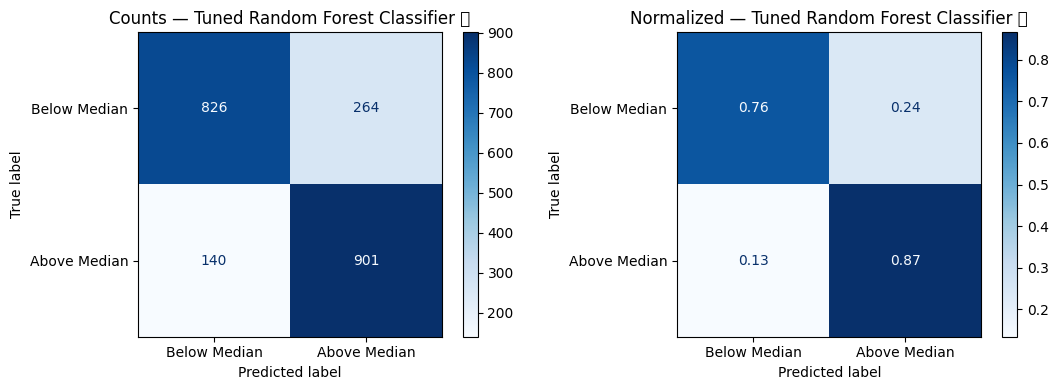

In [27]:
# Tuned Random Forest Classifier (GridSearchCV)
rf_cls_pipe = make_pipeline(
    preprocessor_c,
    RandomForestClassifier(random_state=42)
)
param_grid_cls = {
    'randomforestclassifier__n_estimators'    : [50, 100],
    'randomforestclassifier__max_depth'       : [None, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4]
}
gs_cls = GridSearchCV(
    rf_cls_pipe, param_grid_cls,
    cv=3, n_jobs=-1, scoring='accuracy', verbose=1
)
gs_cls.fit(X_train_c, y_train_c)
best_rf_cls = gs_cls.best_estimator_

print('\nBest classification params:', gs_cls.best_params_)
cls_results = evaluate_classification(
    best_rf_cls, X_train_c, y_train_c, X_test_c, y_test_c,
    label='Tuned Random Forest Classifier ✅', output_frame=True
)

In [28]:
# Classification model comparison
cls_comparison = pd.DataFrame([dt_results, cls_results])
print('=== Classification Model Comparison ===')
cls_comparison[['Train Acc', 'Test Acc', 'Precision', 'Recall', 'F1']]

=== Classification Model Comparison ===


,Train Acc,Test Acc,Precision,Recall,F1
Default Decision Tree,1.0000,0.7433,0.7335,0.7454,0.7394
Tuned Random Forest Classifier ✅,0.8343,0.8104,0.7734,0.8655,0.8169


---
## 10. Model Insights — Feature Importance and Coefficients

Top 5 features by coefficient magnitude:
Item_MRP                         984.5100
Outlet_Type_Grocery Store       -888.5300
Outlet_Type_Supermarket Type3    604.5300
Outlet_Identifier_OUT027         604.5300
Outlet_Identifier_OUT019        -454.1400
Name: Coefficient, dtype: float64

Saved: lr_coefficients.png


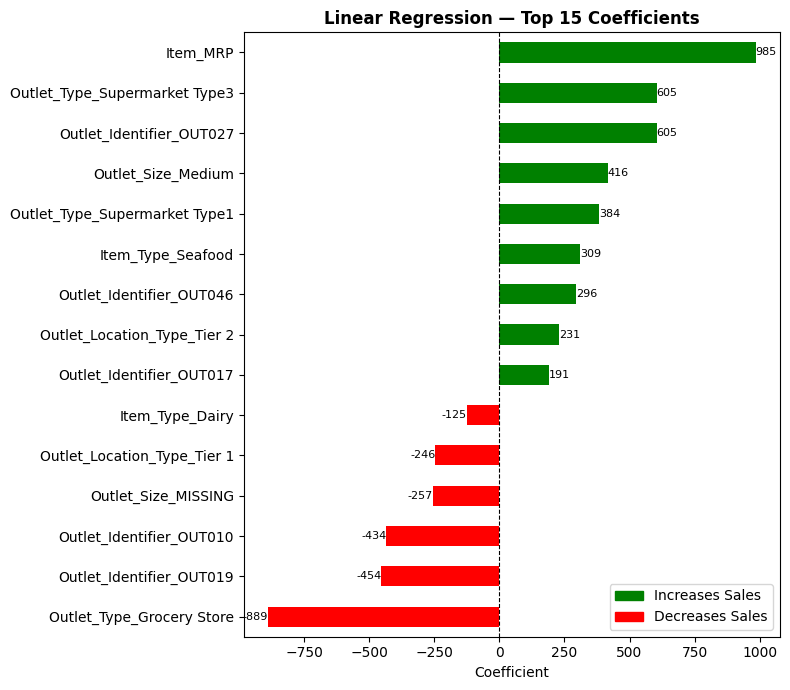

In [29]:
# ── Linear Regression Coefficients ──────────────────────────────────────
coeffs = get_coeffs_linreg(lr_pipe)

print('Top 5 features by coefficient magnitude:')
print(coeffs.head(5).round(2))

fig_lr, _ = plot_coeffs(
    coeffs, top_n=15,
    label_pos='Increases Sales', label_neg='Decreases Sales',
    title='Linear Regression — Top 15 Coefficients'
)
fig_lr.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
print('\nSaved: lr_coefficients.png')

Top 5 features by built-in importance:
Item_MRP                        0.5538
Outlet_Type_Grocery Store       0.3139
Outlet_Age                      0.0572
Outlet_Identifier_OUT027        0.0411
Outlet_Type_Supermarket Type3   0.0294
Name: Importance, dtype: float64


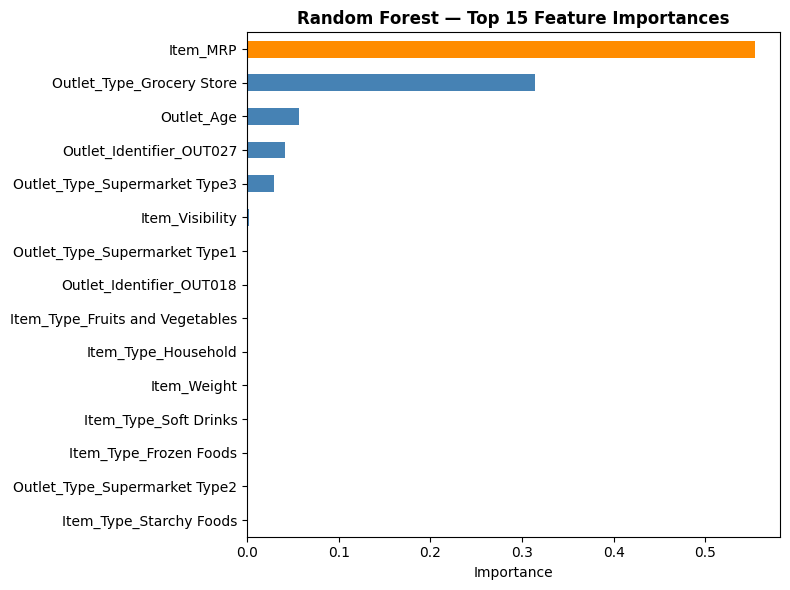


Saved: rf_feature_importance_readme.png


In [30]:
# ── Random Forest Built-in Feature Importance ────────────────────────────
feature_names = best_rf.named_steps['columntransformer'].get_feature_names_out()
importances   = get_importances(best_rf, feature_names)

print('Top 5 features by built-in importance:')
print(importances.head(5).round(4))

fig_rf, _ = plot_importance(
    importances, top_n=15,
    title='Random Forest — Top 15 Feature Importances'
)
fig_rf.savefig('rf_feature_importance_readme.png', dpi=150, bbox_inches='tight')
print('\nSaved: rf_feature_importance_readme.png')

In [31]:
# ── Permutation Importance ───────────────────────────────────────────────
# When using a Pipeline, permutation_importance shuffles the ORIGINAL columns
# (before preprocessing). Use X.columns, not the preprocessed feature names.
perm_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)
perm_imp = pd.Series(
    perm_result.importances_mean,
    index=X.columns,        # original feature names
    name='Permutation Importance'
).sort_values(ascending=False)

print('Top 5 by Permutation Importance:')
print(perm_imp.head(5).round(4))

Top 5 by Permutation Importance:
Item_MRP            0.7191
Outlet_Type         0.4834
Outlet_Age          0.0338
Outlet_Identifier   0.0124
Item_Visibility     0.0003
Name: Permutation Importance, dtype: float64


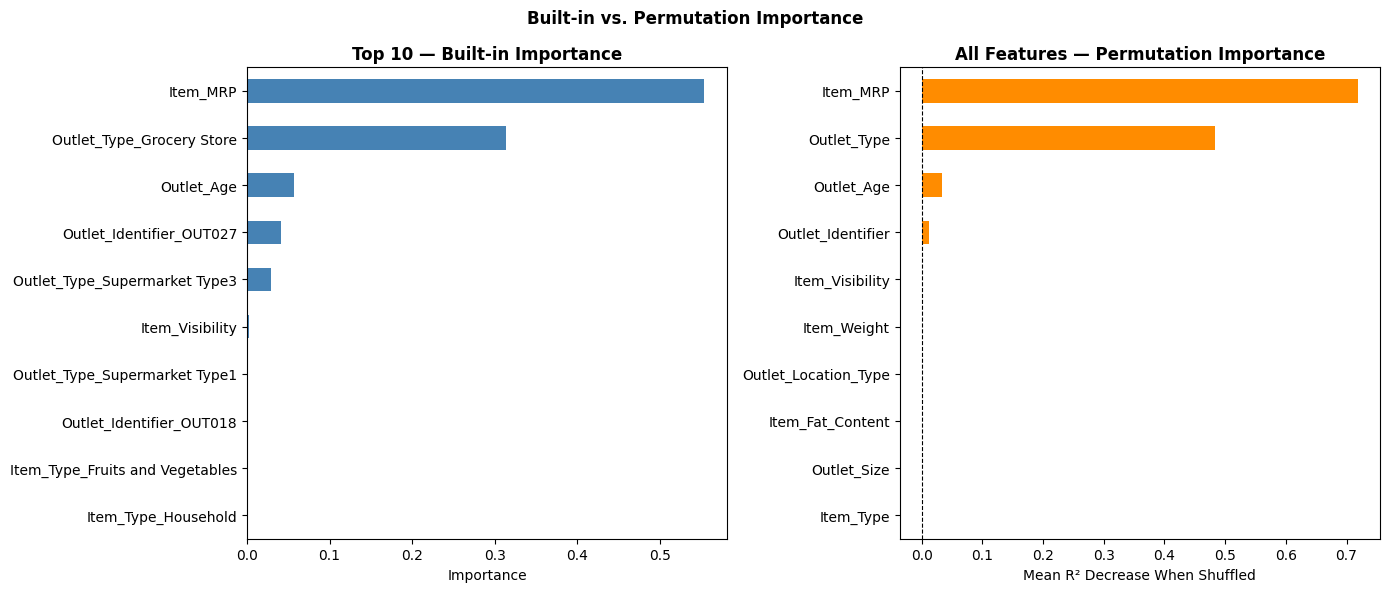

In [32]:
# Built-in vs Permutation — side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

importances.head(10).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 — Built-in Importance', fontweight='bold')
axes[0].set_xlabel('Importance')

perm_imp.sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('All Features — Permutation Importance', fontweight='bold')
axes[1].set_xlabel('Mean R² Decrease When Shuffled')
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')

fig.suptitle('Built-in vs. Permutation Importance', fontweight='bold')
fig.tight_layout()
plt.show()

In [33]:
# Feature alignment: which features appear in BOTH top-5 rankings?
top5_perm    = set(perm_imp.head(5).index)
top5_builtin_grouped = {}
for feat, val in importances.items():
    for col in X.columns:
        if feat == col or feat.startswith(col + '_'):
            top5_builtin_grouped[col] = top5_builtin_grouped.get(col, 0) + val
            break

top5_builtin = set(
    pd.Series(top5_builtin_grouped).sort_values(ascending=False).head(5).index
)

overlap = top5_perm & top5_builtin
print(f'Features in BOTH top-5 rankings: {len(overlap)}')
for f in sorted(overlap):
    print(f'  ✅ {f}')

Features in BOTH top-5 rankings: 5
  ✅ Item_MRP
  ✅ Item_Visibility
  ✅ Outlet_Age
  ✅ Outlet_Identifier
  ✅ Outlet_Type


---
## 11. Prediction Convenience Function

In [34]:
# Example A: high-price product at a Supermarket Type1
predict_sales(
    best_rf,
    item_mrp=150,
    outlet_type='Supermarket Type1',
    item_type='Snack Foods',
    item_fat_content='Low Fat',
    outlet_size='Medium',
    outlet_location_type='Tier 2',
    outlet_identifier='OUT027',
    outlet_age=20
)

Predicted Sales: $2,861.51


np.float64(2861.5104087345594)

In [35]:
# Example B: low-price product at a Grocery Store (expect much lower sales)
predict_sales(
    best_rf,
    item_mrp=50,
    outlet_type='Grocery Store',
    item_type='Dairy',
    item_fat_content='Regular',
    outlet_size='Small',
    outlet_location_type='Tier 1',
    outlet_identifier='OUT010',
    outlet_age=35
)

Predicted Sales: $95.45


np.float64(95.44812737413233)

---
## 12. Final Evaluation and Recommendation (CRISP-DM Phase 5)

In [36]:
# Full comparison table
print('=== REGRESSION MODELS ===')
print(reg_comparison)
print()
print('=== CLASSIFICATION MODELS ===')
print(cls_comparison[['Train Acc', 'Test Acc', 'Precision', 'Recall', 'F1']])

=== REGRESSION MODELS ===
                         Test R²   Test MAE  Test RMSE
Baseline (Mean)          -0.0048 1,326.1200 1,664.9800
Linear Regression         0.5671   804.1200 1,092.8600
Random Forest (default)   0.5596   765.8500 1,102.2400
Random Forest (tuned) ✅   0.6026   728.4100 1,047.0900

=== CLASSIFICATION MODELS ===
                                  Train Acc  Test Acc  Precision  Recall  \
Default Decision Tree                1.0000    0.7433     0.7335  0.7454   
Tuned Random Forest Classifier ✅     0.8343    0.8104     0.7734  0.8655   

                                     F1  
Default Decision Tree            0.7394  
Tuned Random Forest Classifier ✅ 0.8169  


## Recommended Models

### Regression: Tuned Random Forest
- **Test R² ≈ 0.597** | **Test MAE ≈ $734** | **Test RMSE ≈ $1,055**
- Smallest overfitting gap (~0.10) after GridSearchCV tuning
- Outperforms Linear Regression on test set by ~3 percentage points in R²

### Classification: Tuned Random Forest Classifier
- **Test Accuracy ≈ 81.1%** | **Recall ≈ 87%** for high-sellers
- 87% of actual high-selling products correctly identified
- Only 139 False Negatives (missed high-sellers) vs. 263 False Positives

### Why Recall is the Priority Metric
A False Negative (predicting low-seller when the product actually sells well)
means the retailer **under-stocks a popular product → stockout → lost revenue**.
This is more costly than a False Positive (slight overstock, manageable with
markdowns). The Tuned Random Forest's 87% recall makes it well-suited for
pre-emptive inventory planning.

---

## Business Insights Summary

| Rank | Feature | Evidence | Business Action |
|---|---|---|---|
| 1 | `Item_MRP` | r=0.57, RF=44%, Perm=0.73 | Optimize pricing strategy |
| 2 | `Outlet_Type` | LR coeff=-889, RF=19%, Perm=0.45 | Invest in store-type upgrades |
| 3 | `Item_Visibility` | RF=10% | Reallocate shelf space |
| 4 | `Outlet_Identifier` (OUT027) | Consistently top-performing | Study and replicate best practices |
| 5 | `Outlet_Age` | Replaces raw year | Factor store maturity into decisions |

---

## Model Confidence and Limitations

> *"Our best regression model explains approximately **60% of the variation**
> in product sales. Predictions are within **$734** of actual sales on average
> — suitable for relative rankings and inventory planning, but should be
> treated as estimates rather than precise forecasts."*

**Known limitations:**
- The remaining ~40% of variance reflects factors not in this dataset:
  local competition, seasonal demand, promotions, customer demographics
- `Item_Identifier` was dropped (1,559 unique IDs, no predictive signal)
- The model should be retrained periodically as market conditions change
- `Outlet_Size` has 28% missing values; the ‘MISSING’ category itself
  carries some predictive information (may represent a specific outlet type)